## Genetic Algorithm to Generate new Telecom Bundles

* the data we will use in this process should come from product dimension table (products profile). these products represent the coordinates in a design space. A genetic algorithm wanders through that space like an explorer with a mutation ray, constantly asking: “Is this bundle more attractive than the previous ones?”. and our popularity model becomes the fitness oracle. Evolution proposes bundles; the model judges them.

In [57]:
import pandas as pd
import numpy as np
import joblib
import re

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns
import matplotlib.pyplot as plt 

RANDOM_STATE: int = 42 

In [39]:
DATA_PATH: str =  r"..\..\..\datasets\product_profile\dim_product.csv"

data = pd.read_csv(DATA_PATH)
data.shape

(1415, 12)

### Data Preprocessing

In [40]:
data.head(10)

,bundle_id,bundle_name,product_category,category_description,usage_type,configured_volume,speed,business_categorisation,price,bundle_type,validity,service_class_category
0,80109,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,CVM VOICE ACCELERATION,CHARGED,175mins,NaN,CVM Voice Acceleration,2400.0,BUNDLE_VOICE,30 days,PREPAID
1,50188,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,ASIA AND AMERICA,CHARGED,30MIN,NaN,ASIA and AMERICA,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID
2,3677801,NDEKO Net Bonus-170MB 1 Jour,BONUS_DATA,MAGIC NET,FREE,170MB,NaN,MAGIC NET,NaN,BUNDLE_DATA,1 days,NaN
3,3697901,Forfait Bonus-2.4GB 1 jour,BONUS_DATA,WIDGE NDEKO,FREE,2.4GB,NaN,Widge Data Bundle,NaN,BUNDLE_DATA,1 days,NaN
4,3696801,Forfait MagicNet BONUS-10.7GB 1 Jour,BONUS_DATA,MAGIC NET,FREE,10.7GB,NaN,MAGIC NET,NaN,BUNDLE_DATA,1 days,NaN
5,35123,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,LTEBUSINESS,CHARGED,150GB,NaN,EBU,35000.0,BUNDLE_DATA,30 days,HYBRID
6,50096,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,EBU INTERNATIONAL VOICE BUNDLE,CHARGED,5MIN,NaN,EBU_INT_VOICE_BUNDLE,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID
7,36985,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,NDEKO MIX,CHARGED,7GB,NaN,Ndeko Mix,11000.0,BUNDLE_DATA,7 days,PREPAID
8,50014,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,2MIN,NaN,NaN,490.0,INT_BUNDLE_VOICE,30 days,PREPAID
9,35502,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,LTEBUSINESS,CHARGED,Unlimited,2Mbps,EBU,80050.0,BUNDLE_DATA,30 days,PREPAID


In [52]:
data = data[~data['bundle_name'].isna()]
data.shape

(1131, 17)

In [41]:
# remove free bundes
data = data[~((~data['product_category'].isna()) & (data['product_category'].str.contains("BONUS")))]
data.shape

(1158, 12)

* Load the train popularity model and assign popularity Score for each bundle based on our popuarity model

In [42]:
def feature_engineering_apply(df, te, st_model, pca, scaler, numeric_cols):
    df = df.copy()
    cat_cols = ["bundle_type", "season", "usage_type", "service_class_category"]

    df['week_sin'] = np.sin(2 * np.pi * df['week_number'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_number'] / 52)

    # use te.transform (NO y)
    df[cat_cols] = te.transform(df[cat_cols])

    name_emb = st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
    name_emb_pca = pca.transform(name_emb)
    for i in range(name_emb_pca.shape[1]):
        df[f"name_emb_{i}"] = name_emb_pca[:, i]

    numeric_df = df[numeric_cols].copy()
    X = scaler.transform(numeric_df)
    X = pd.DataFrame(X, columns=numeric_cols)

    return X


def load_bundle_model(model_path="bundle_popularity_model.pkl"):
    artifacts = joblib.load(model_path)
    
    model = artifacts["model"]
    te = artifacts["target_encoder"]
    st_model = artifacts["sentence_model"]
    pca = artifacts["pca"]
    scaler = artifacts["scaler"]
    numeric_cols = artifacts["numeric_cols"]

    return model, te, st_model, pca, scaler, numeric_cols


def predict_bundle_popularity(df_input, model, te, st_model, pca, scaler, numeric_cols):
    """
    df_input: dataframe with raw bundle features
    returns predicted popularity
    """

    # Apply same feature engineering
    X_fe = feature_engineering_apply(
        df_input,
        te=te,
        st_model=st_model,
        pca=pca,
        scaler=scaler,
        numeric_cols=numeric_cols
    )

    preds = model.predict(X_fe)

    return preds

model, te, st_model, pca, scaler, numeric_cols = load_bundle_model(r"C:\Users\Alber\Desktop\uni\GraduationProject\mintel\notebooks\popularity\bundle_popularity_model.pkl")

new_data = pd.DataFrame({
    "week_number":[1],
    "season":["spring"],
    "bundle_name":["Forfait weekend 780MB 1jours@350F"],
    "bundle_type":["BUNDLE_DATA"],
    "price":[350.0],
    "usage_type":["CHARGED"],
    "service_class_category":["PREPAID"],
    "configured_volume_mb":[780.0],
    "configured_volume_min":[0.0],
    "configured_volume_sms":[0.0],
    "validity_hours":[24.0],
    "is_illimite":[0]
})

prediction = predict_bundle_popularity(
    new_data,
    model,
    te,
    st_model,
    pca,
    scaler,
    numeric_cols
)

print("Predicted popularity:", prediction)

Predicted popularity: [0.71087035]


In [43]:
# Extract Configured Volumes 'configured_volume'
def extract_conf_volume_values(volume_str):
    """
    Extract MB, minutes, and SMS from configured_volume string.
    Handles: GB (→ MB), MB, Minutes, SMS, commas, combinations, addition formats, etc.
    """
    if pd.isna(volume_str) or volume_str is None:
        return {'mb': None, 'min': None, 'sms': None}
    
    original_str = str(volume_str)
    if original_str.lower() in ['unlimited', 'illimité', 'illimite']:
        return {'mb': None, 'min': None, 'sms': None}
    
    volume_str = original_str.replace(',', '.')
    volume_str_upper = volume_str.upper()
    
    mb_value = None
    min_value = None
    sms_value = None
    
    # extract GB and convert to MB
    gb_pattern = r'(\d+(?:\.\d+)?)\s*G(?:B)?\b'
    gb_matches = re.findall(gb_pattern, volume_str_upper)
    if gb_matches:
        mb_value = sum(float(gb) for gb in gb_matches) * 1024
    
    # extract MB
    mb_pattern = r'(\d+(?:\.\d+)?)\s*MB\b'
    mb_matches = re.findall(mb_pattern, volume_str_upper)
    if mb_matches:
        total_mb = sum(float(mb) for mb in mb_matches)
        mb_value = total_mb if mb_value is None else mb_value + total_mb
    
    # extract minutes
    min_pattern = r'(\d+(?:\.\d+)?)\s*MINS?\b'
    min_matches = re.findall(min_pattern, volume_str_upper)
    add_pattern_min = r'(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b'
    add_match_min = re.search(add_pattern_min, volume_str_upper)
    
    if add_match_min:
        min_value = float(add_match_min.group(1)) + float(add_match_min.group(2))
    elif min_matches:
        min_value = sum(float(m) for m in min_matches)
    
    # extract SMS
    sms_pattern = r'(\d+(?:\.\d+)?)\s*SMS\b'
    sms_matches = re.findall(sms_pattern, volume_str_upper)
    if sms_matches:
        sms_value = sum(float(sms) for sms in sms_matches)
    
    # handle "/" formats like "200/40 mins"
    slash_pattern = r'(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)'
    slash_match = re.search(slash_pattern, volume_str)
    if slash_match and 'MIN' in volume_str_upper:
        if min_value is None:
            min_value = float(slash_match.group(2))
        if mb_value is None:
            mb_value = float(slash_match.group(1))
    
    # handle seconds
    sec_pattern = r'(\d+(?:\.\d+)?)\s*SEC\b'
    sec_matches = re.findall(sec_pattern, volume_str_upper)
    if sec_matches:
        sec_as_min = sum(float(sec) for sec in sec_matches) / 60.0
        min_value = sec_as_min if min_value is None else min_value + sec_as_min
    
    return {'mb': mb_value, 'min': min_value, 'sms': sms_value}


volume_extracted = data['configured_volume'].apply(extract_conf_volume_values)
data['configured_volume_mb'] = volume_extracted.apply(lambda x: x['mb'] if x['mb'] is not None else 0.0)
data['configured_volume_min'] = volume_extracted.apply(lambda x: x['min'] if x['min'] is not None else 0.0)
data['configured_volume_sms'] = volume_extracted.apply(lambda x: x['sms'] if x['sms'] is not None else 0.0)

In [44]:
def parse_validity_to_hours(val):
    """
    Convert variants like '7 days', '4 hours', '3 months', '1  days', None -> hours (float)
    Uses 30 days per month convention for telecom.
    Returns np.nan if cannot parse.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        # unexpected numeric — treat as days
        return float(val) * 24.0
    s = str(val).strip().lower()
    # correct double spaces
    s = re.sub(r"\s+", " ", s)
    # find number
    m = re.match(r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = m.group(3) or "days"
    if "hour" in unit:
        return num
    if "day" in unit:
        return num * 24.0
    if "month" in unit:
        return num * 30.0 * 24.0
    # fallback assume days
    return num * 24.0

data['validity_hours'] = data['validity'].apply(parse_validity_to_hours)

In [53]:
def is_illimite(bundle_name: str) -> int:
    return 1 if "illimite" in bundle_name.lower() else 0

data['is_illimite'] = data['bundle_name'].apply(is_illimite)

In [48]:
data.head(10)

,bundle_id,bundle_name,product_category,category_description,usage_type,configured_volume,speed,business_categorisation,price,bundle_type,validity,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,is_illimite
0,80109,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,CVM VOICE ACCELERATION,CHARGED,175mins,NaN,CVM Voice Acceleration,2400.0,BUNDLE_VOICE,30 days,PREPAID,0.0,175.0,0.0,720.0,0
1,50188,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,ASIA AND AMERICA,CHARGED,30MIN,NaN,ASIA and AMERICA,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,30.0,0.0,720.0,0
5,35123,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,LTEBUSINESS,CHARGED,150GB,NaN,EBU,35000.0,BUNDLE_DATA,30 days,HYBRID,153600.0,0.0,0.0,720.0,0
6,50096,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,EBU INTERNATIONAL VOICE BUNDLE,CHARGED,5MIN,NaN,EBU_INT_VOICE_BUNDLE,1200.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,5.0,0.0,720.0,0
7,36985,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,NDEKO MIX,CHARGED,7GB,NaN,Ndeko Mix,11000.0,BUNDLE_DATA,7 days,PREPAID,7168.0,0.0,0.0,168.0,0
8,50014,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,2MIN,NaN,NaN,490.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,2.0,0.0,720.0,0
9,35502,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,LTEBUSINESS,CHARGED,Unlimited,2Mbps,EBU,80050.0,BUNDLE_DATA,30 days,PREPAID,0.0,0.0,0.0,720.0,0
10,37333,NEW RESIDENTIAL@18500F,BUNDLE_DATA,RESIDENTIAL,CHARGED,90GB,15Mbps,Residential Offer,18500.0,BUNDLE_DATA,30 days,HYBRID,92160.0,0.0,0.0,720.0,0
11,50203,Forfait appels Liban 3 mins 45sec 30 jours@350F,INT_BUNDLE_VOICE,VOICE INTERNATIONAL BUNDLE,CHARGED,3MIN,NaN,VOICE INTERNATIONAL BUNDLE,350.0,INT_BUNDLE_VOICE,30 days,PREPAID,0.0,3.0,0.0,720.0,0
12,35260,SHart + Extra Entreprise H4@100700,BUNDLE_DATA,SMARTBUSINESS,CHARGED,10240MB,NaN,Smart Combo Platinium,100700.0,BUNDLE_DATA,30 days,NaN,10240.0,0.0,0.0,720.0,0


In [55]:
def convert_operator_bundles(df):

    df = df.copy()

    # default week these parameters in depens on real-time 
    df["week_number"] = 1
    df["season"] = "spring"

    df["is_illimite"] = df["configured_volume"].str.contains(
        "unlimited", case=False, na=False
    ).astype(int)

    return df[[
        "week_number",
        "season",
        "bundle_name",
        "bundle_type",
        "price",
        "usage_type",
        "service_class_category",
        "configured_volume_mb",
        "configured_volume_min",
        "configured_volume_sms",
        "validity_hours",
        "is_illimite"
    ]]


prepared_data = convert_operator_bundles(data)

popularity = predict_bundle_popularity(
    prepared_data,
    model,
    te,
    st_model,
    pca,
    scaler,
    numeric_cols
)

prepared_data["predicted_popularity"] = popularity

In [56]:
prepared_data.head(10)

,week_number,season,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,is_illimite,predicted_popularity
0,1,spring,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,2400.0,CHARGED,PREPAID,0.0,175.0,0.0,720.0,0,0.201396
1,1,spring,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,30.0,0.0,720.0,0,0.246380
5,1,spring,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,35000.0,CHARGED,HYBRID,153600.0,0.0,0.0,720.0,0,0.205877
6,1,spring,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,5.0,0.0,720.0,0,0.174614
7,1,spring,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,11000.0,CHARGED,PREPAID,7168.0,0.0,0.0,168.0,0,0.238171
8,1,spring,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,490.0,CHARGED,PREPAID,0.0,2.0,0.0,720.0,0,0.159268
9,1,spring,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,80050.0,CHARGED,PREPAID,0.0,0.0,0.0,720.0,1,0.252609
10,1,spring,NEW RESIDENTIAL@18500F,BUNDLE_DATA,18500.0,CHARGED,HYBRID,92160.0,0.0,0.0,720.0,0,0.211036
11,1,spring,Forfait appels Liban 3 mins 45sec 30 jours@350F,INT_BUNDLE_VOICE,350.0,CHARGED,PREPAID,0.0,3.0,0.0,720.0,0,0.138308
12,1,spring,SHart + Extra Entreprise H4@100700,BUNDLE_DATA,100700.0,CHARGED,NaN,10240.0,0.0,0.0,720.0,0,0.204923


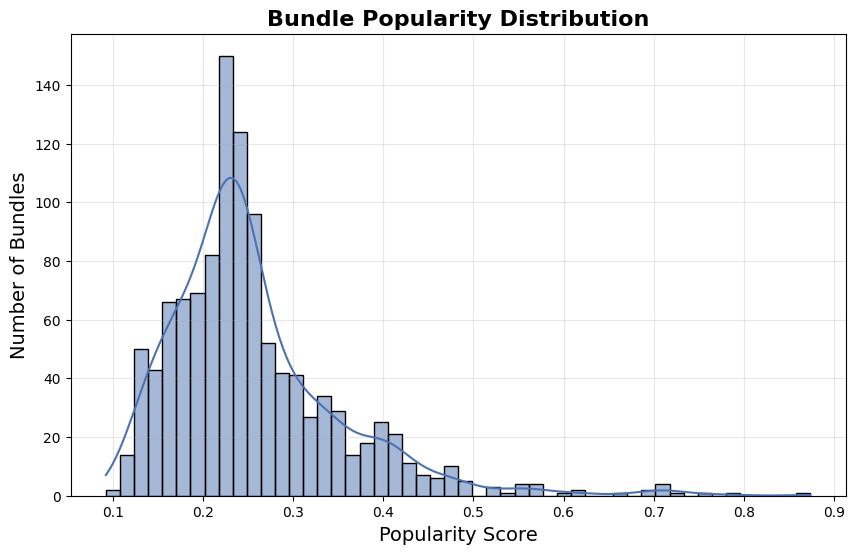

In [60]:
plt.figure(figsize=(10,6))
sns.histplot(prepared_data['predicted_popularity'], bins=50, kde=True, color="#4C72B0", edgecolor='black')
plt.title("Bundle Popularity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=14)
plt.ylabel("Number of Bundles", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

### Genetic Algorithm Modeling

In [63]:
candidates = prepared_data.copy()
candidates.head(10)

,week_number,season,bundle_name,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,is_illimite,predicted_popularity
0,1,spring,Inbound Voice Acceleration 175 mins 30Jours@2400F,BUNDLE_VOICE,2400.0,CHARGED,PREPAID,0.0,175.0,0.0,720.0,0,0.201396
1,1,spring,Int Bundle ASIA and AMERICA 30min 30jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,30.0,0.0,720.0,0,0.246380
5,1,spring,MTNBIZ+ 150GB@35000F,BUNDLE_DATA,35000.0,CHARGED,HYBRID,153600.0,0.0,0.0,720.0,0,0.205877
6,1,spring,Forfait appels Senegal 5 mins 30 jours@1200F,INT_BUNDLE_VOICE,1200.0,CHARGED,PREPAID,0.0,5.0,0.0,720.0,0,0.174614
7,1,spring,Ndeko Mix 300Mins + 7GB 7 jours@11000F,BUNDLE_DATA,11000.0,CHARGED,PREPAID,7168.0,0.0,0.0,168.0,0,0.238171
8,1,spring,Forfait appels Senegal 2 mins 30 jours @490F,INT_BUNDLE_VOICE,490.0,CHARGED,PREPAID,0.0,2.0,0.0,720.0,0,0.159268
9,1,spring,Forfait LTE Business 30 jours 2 mbps@80050F,BUNDLE_DATA,80050.0,CHARGED,PREPAID,0.0,0.0,0.0,720.0,1,0.252609
10,1,spring,NEW RESIDENTIAL@18500F,BUNDLE_DATA,18500.0,CHARGED,HYBRID,92160.0,0.0,0.0,720.0,0,0.211036
11,1,spring,Forfait appels Liban 3 mins 45sec 30 jours@350F,INT_BUNDLE_VOICE,350.0,CHARGED,PREPAID,0.0,3.0,0.0,720.0,0,0.138308
12,1,spring,SHart + Extra Entreprise H4@100700,BUNDLE_DATA,100700.0,CHARGED,NaN,10240.0,0.0,0.0,720.0,0,0.204923
